#### Imporrt Libraries

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

#### Load Data

In [5]:
df = pd.read_csv("C:\\Users\\ACER\\Documents\\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\\data\\MCU_Dataset.csv")

df.head()

,title,type,release_year,mcu_phase_number,imdb_rating,rt_tomato_meter,rt_audience_score,production_budget,domestic_box_office,international_box_office,...,director,profit,roi,decade,success_category,success_encoded,success_score,imdb_scaled,audience_scaled,roi_scaled
0,iron man,Movie,2008,1,7.9,94,91,140000000,319034126,266762121,...,Jon Favreau,445796247,318.425891,2000,Hit,2,73.291607,0.871795,0.893939,0.386721
1,the incredible hulk,Movie,2008,1,6.6,67,70,140000000,134806913,128620638,...,Louis Leterrier,123427551,88.162536,2000,Hit,2,42.603623,0.538462,0.575758,0.126414
2,iron man 2,Movie,2010,1,6.9,72,71,200000000,312433331,311500000,...,Jon Favreau,423933331,211.966666,2010,Hit,2,50.333809,0.615385,0.590909,0.266372
3,thor,Movie,2011,1,7.0,77,76,150000000,181030624,268295994,...,Kenneth Brangh,299326618,199.551079,2010,Hit,2,53.211113,0.641026,0.666667,0.252336
4,captain america the first avenger,Movie,2011,1,6.9,79,75,140000000,176654505,193915269,...,Joe Johnston,230569774,164.692696,2010,Hit,2,50.548732,0.615385,0.651515,0.212930


Features

In [6]:
cluster_df = df[
[
    "imdb_rating",
    "rt_audience_score",
    "production_budget",
    "worldwide_box_office",
    "roi"
]
]

#### Scaling

In [7]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    cluster_df
)

#### Elbow Method

In [8]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(
        kmeans.inertia_
    )

#### Plot Elbow

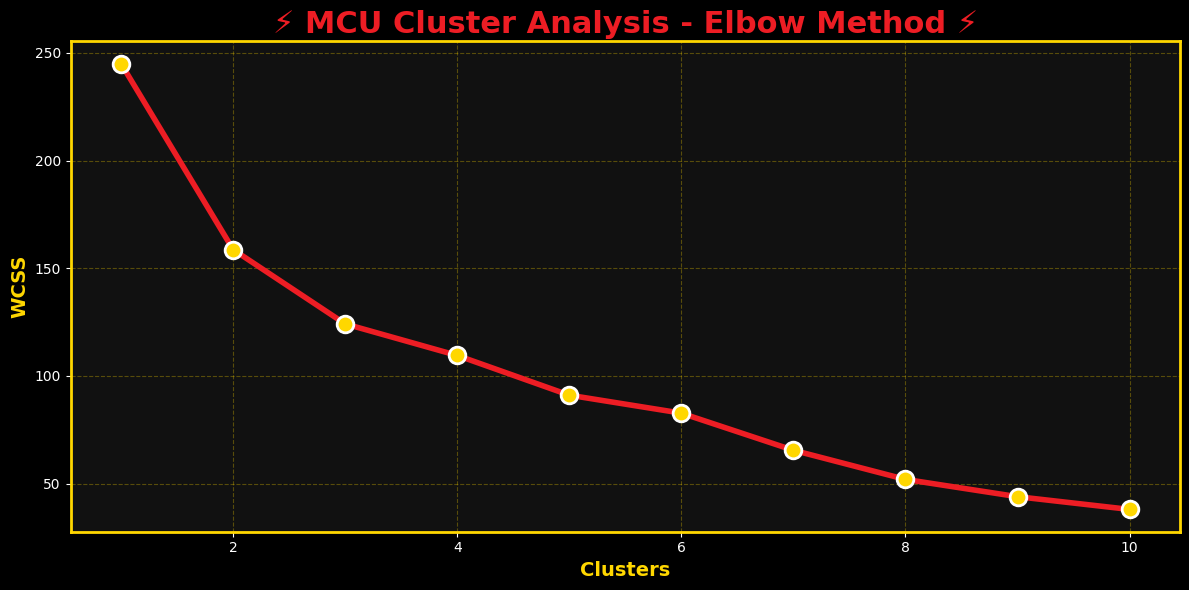

In [11]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(12,6))

fig.patch.set_facecolor("black")
ax.set_facecolor("#111111")

ax.plot(
    range(1,11),
    wcss,
    color="#ED1D24",
    linewidth=4,
    marker="o",
    markersize=12,
    markerfacecolor="gold",
    markeredgewidth=2,
    markeredgecolor="white"
)

ax.set_title(
    "⚡ MCU Cluster Analysis - Elbow Method ⚡",
    fontsize=22,
    color="#ED1D24",
    weight="bold"
)

ax.set_xlabel(
    "Clusters",
    fontsize=14,
    color="gold",
    weight="bold"
)

ax.set_ylabel(
    "WCSS",
    fontsize=14,
    color="gold",
    weight="bold"
)

ax.grid(
    linestyle="--",
    alpha=0.3,
    color="gold"
)

for spine in ax.spines.values():
    spine.set_color("gold")
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(
    r"C:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\visuals\MCU_Cluster_Analysis_Elbow_Method.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Create KMeans

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df["cluster"] = kmeans.fit_predict(
    scaled_data
)

Check Results

In [14]:
df[
[
"title",
"cluster"
]
].head(40)

,title,cluster
0,iron man,2
1,the incredible hulk,1
2,iron man 2,2
3,thor,2
4,captain america the first avenger,2
5,the avengers,0
6,iron man 3,0
7,thor the dark world,2
8,captain america the winter soldier,2
9,guardians of the galaxy,2


#### Understanding Clusters

In [15]:
cluster_summary = df.groupby(
    "cluster"
)[
[
    "worldwide_box_office",
    "imdb_rating",
    "roi"
]
].mean()

print(cluster_summary)

         worldwide_box_office  imdb_rating         roi
cluster                                               
0                1.587502e+09     7.740000  579.993737
1                2.013070e+08     5.900000   83.749982
2                4.852950e+08     7.251724  185.894389


In [26]:
cluster_names = {

0:"MCU Legends",

1:"Successful Heroes",

2:"Struggling Titles"

}
df
df["cluster_name"] = df[
    "cluster"
].map(cluster_names)

C:\Users\ACER\AppData\Local\Temp\ipykernel_18468\4139664367.py:8: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.scatterplot(


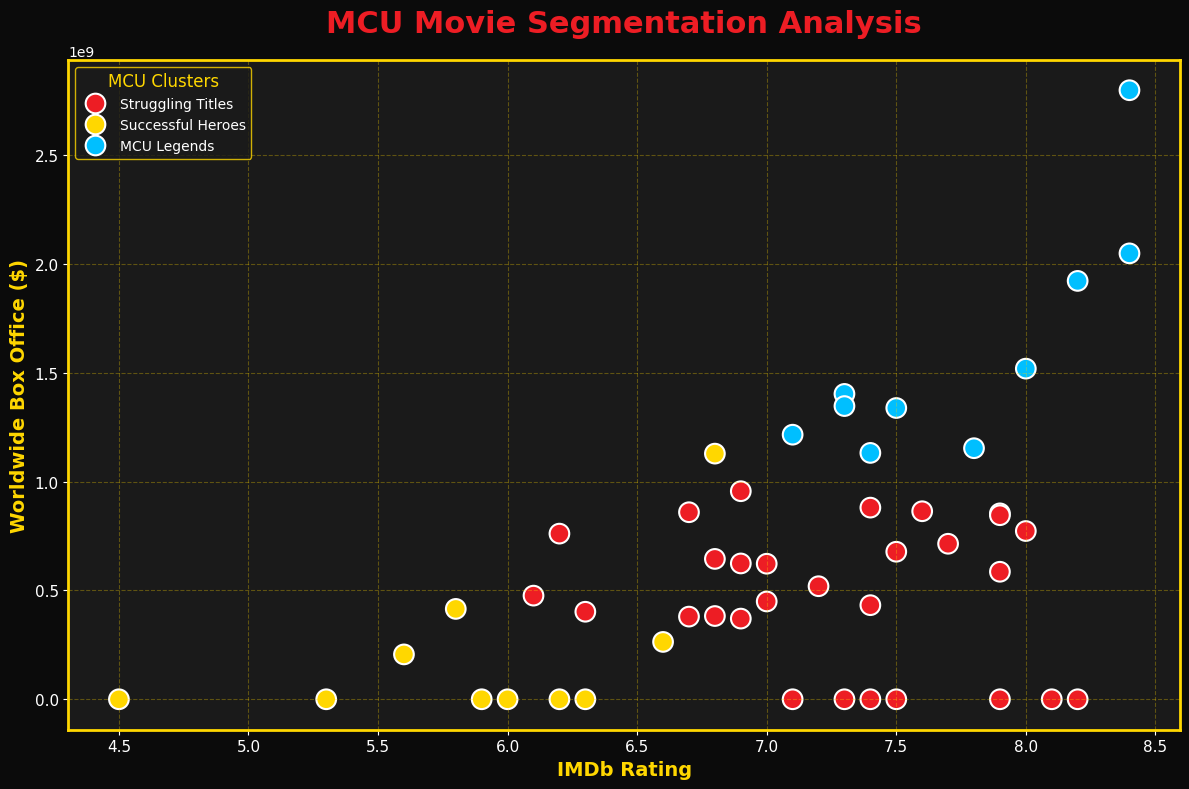

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure
plt.figure(figsize=(12, 8), facecolor="#0B0B0B")

# Scatter Plot
ax = sns.scatterplot(
    data=df,
    x="imdb_rating",
    y="worldwide_box_office",
    hue="cluster_name",
    palette=["#ED1D24", "#FFD700", "#00BFFF", "#FF4500"],
    s=200,
    edgecolor="white",
    linewidth=1.5
)

# Background
ax.set_facecolor("#1A1A1A")

# Title
plt.title(
    "MCU Movie Segmentation Analysis",
    fontsize=22,
    color="#ED1D24",
    fontweight="bold",
    pad=20
)

# Axis Labels
plt.xlabel(
    "IMDb Rating",
    fontsize=14,
    color="gold",
    fontweight="bold"
)

plt.ylabel(
    "Worldwide Box Office ($)",
    fontsize=14,
    color="gold",
    fontweight="bold"
)

# Tick Colors
plt.xticks(color="white", fontsize=11)
plt.yticks(color="white", fontsize=11)

# Grid
plt.grid(
    linestyle="--",
    alpha=0.3,
    color="gold"
)

# Legend Styling
legend = plt.legend(
    title="MCU Clusters",
    facecolor="#1A1A1A",
    edgecolor="gold"
)

plt.setp(legend.get_title(), color="gold", fontsize=12)
for text in legend.get_texts():
    text.set_color("white")

# Gold Border
for spine in ax.spines.values():
    spine.set_color("gold")
    spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(
    r"C:\Users\ACER\Documents\Marvel Cinematic Universe Intelligence Dashboard & Success Prediction System\visuals\MCU_Movie_Segmentation_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
cluster_df = df[
[
    "success_score",
    "worldwide_box_office",
    "imdb_rating"
]
]

In [25]:
cluster_names = {

0: "MCU Legends",

1: "Successful Heroes",

2: "Struggling Titles"

}

df["cluster_name"] = df["cluster"].map(
    cluster_names
)

In [27]:
df.columns

Index(['title', 'type', 'release_year', 'mcu_phase_number', 'imdb_rating',
       'rt_tomato_meter', 'rt_audience_score', 'production_budget',
       'domestic_box_office', 'international_box_office',
       'worldwide_box_office', 'trailer_views', 'trailer_likes',
       'trailer_count', 'runtime (mins)', 'genres', 'num votes',
       'opening weekend', 'director', 'profit', 'roi', 'decade',
       'success_category', 'success_encoded', 'success_score', 'imdb_scaled',
       'audience_scaled', 'roi_scaled', 'cluster', 'cluster_name',
       'Marvel_Cluster'],
      dtype='str')

In [28]:
df[
[
    "title",
    "cluster",
    "cluster_name"
]
].head(10)

,title,cluster,cluster_name
0,iron man,2,Struggling Titles
1,the incredible hulk,1,Successful Heroes
2,iron man 2,2,Struggling Titles
3,thor,2,Struggling Titles
4,captain america the first avenger,2,Struggling Titles
5,the avengers,0,MCU Legends
6,iron man 3,0,MCU Legends
7,thor the dark world,2,Struggling Titles
8,captain america the winter soldier,2,Struggling Titles
9,guardians of the galaxy,2,Struggling Titles


In [29]:
df.to_csv(
    "Marvel_MCU_Final_Analytics_Dataset_Power_BI.csv",
    index=False
)